# TSARA — combining measurements without inventing any

**Phase 4 walkthrough.** Run top to bottom. Every number and figure below is
produced by the package itself from data manufactured in this notebook. No real
measurement is read anywhere and nothing needs mounting to run it.

---

## Why this phase needs more proof than the last three

Everything before this point applies a **declared, exact, one-to-one map**. A
unit conversion multiplies by a number the manifest states. A per-point sigma
comes from a budget the manifest states. A timestamp moves to the middle of the
cell whose boundaries the file states. Each of those is invertible, and the
product still records what went in.

Nothing in this phase is. A binned value is a weighted mean **no instrument
reported**, formed from many values, and there is no way back to them. That
asymmetry is why `docs/METHODS.md` §11.1 sets out five kinds of evidence for
this phase, and why this notebook spends most of its length on evidence rather
than on description.

The other thing that changes here: ingestion carries its own correctness
signal. A file parses or it does not; a schema validates or it does not. A
transformation carries none. A binned value, a propagated sigma and an
interpolated position all come back looking perfectly reasonable when they are
wrong.

In [1]:
import tempfile
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tsara.align import bin_streams_onto_cells
from tsara.core.support import CellBounds
from tsara.synthetic import generate
from tsara.synthetic.config import SyntheticConfig

# --- figure style (identical to notebooks 01, 02 and 03) -------------------
C1, C2, C3 = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, SURFACE = "#e1e0d9", "#fcfcfb"

plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "axes.edgecolor": "#c3c2b7",
        "axes.linewidth": 0.8,
        "axes.labelcolor": INK2,
        "axes.titlecolor": INK,
        "axes.titlesize": 11,
        "axes.titleweight": "normal",
        "axes.titlelocation": "left",
        "axes.labelsize": 9.5,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "xtick.labelsize": 8.5,
        "ytick.labelsize": 8.5,
        "grid.color": GRID,
        "grid.linewidth": 0.7,
        "grid.linestyle": "-",
        "legend.frameon": False,
        "legend.fontsize": 9,
        "font.size": 9.5,
        "lines.linewidth": 1.4,
        "figure.dpi": 110,
    }
)


def finish(
    ax, title=None, sub=None, ylab=None, xlab=None, legend=False, grid_axis="y", loc="upper right"
):
    """Apply the shared chrome: left-aligned title, muted subtitle, hairline grid."""
    if title:
        ax.set_title(title, pad=19 if sub else 8)
    if sub:
        ax.text(0, 1.025, sub, transform=ax.transAxes, fontsize=8.8, color=MUTED, va="bottom")
    if ylab:
        ax.set_ylabel(ylab)
    if xlab:
        ax.set_xlabel(xlab)
    if grid_axis:
        ax.grid(True, axis=grid_axis, alpha=0.9)
    ax.set_axisbelow(True)
    if legend:
        ax.legend(loc=loc)


def hhmm(ax, fmt="%H:%M"):
    """Label the x axis as clock time; the date belongs in the title."""
    ax.xaxis.set_major_formatter(mdates.DateFormatter(fmt))


def bounds_of(stream):
    """Cell start and stop of a stream, as datetime64 arrays for plotting."""
    edges = stream["time_bnds"].values
    return edges[:, 0], edges[:, 1]


def cells_of(stream):
    """Return a stream's cells as the CellBounds the binning primitive takes."""
    edges = stream["time_bnds"].values
    return CellBounds(
        start_ns=edges[:, 0].astype("datetime64[ns]").astype("int64"),
        stop_ns=edges[:, 1].astype("datetime64[ns]").astype("int64"),
    )


def break_gaps(clock, values, tolerance=5.0):
    """Insert a NaN wherever the clock jumps, so no line is drawn across a gap.

    matplotlib rules a straight segment between consecutive points, so a record
    with a hole in it renders as a smooth ramp across the hole -- an
    interpolation of exactly the kind TSARA refuses to perform on a gas.
    """
    clock, values = np.asarray(clock), np.asarray(values, dtype=float)
    steps = np.diff(clock).astype("timedelta64[ms]").astype(float)
    gaps = np.where(steps > tolerance * np.median(steps))[0]
    if gaps.size == 0:
        return clock, values
    return np.insert(clock, gaps + 1, clock[gaps]), np.insert(values, gaps + 1, np.nan)


SECOND = 1_000_000_000

_work = tempfile.TemporaryDirectory()
WORK = Path(_work.name)

print("ready")

ready


---
## 1. The one operation

TSARA joins data in exactly one way:

> **every value is averaged onto the target cells, weighted by how much of it
> falls inside each one.**

That is the whole of it. Everything this phase produces is that operation with
a different choice of target. A species pair for a regression targets the
**wider-supported** member's own cells. A campaign matrix for receptor
modelling targets a **uniform grid**. They are not two designs, and writing
them as two implementations was a design inversion caught during the build —
`pair_species` is now `bin_streams_onto_cells` with two variables selected and
incomplete rows dropped.

The function is deliberately **variable-agnostic**. It does not know what a
species is. It takes whatever it is handed — raw concentrations now, baselines
and enhancements once Phase 5 computes them, met, anything a later stage
invents — and puts it on the support asked for.

Before any real-shaped data, here is the arithmetic on a case small enough to
check with a pencil.

In [2]:
import xarray as xr


def demo_cells(start_s, width_s, n):
    """Return ``n`` abutting cells of ``width_s`` seconds."""
    start = (np.arange(n, dtype=np.int64) * int(width_s * SECOND)) + int(start_s * SECOND)
    return CellBounds(start_ns=start, stop_ns=start + int(width_s * SECOND))


def demo_stream(bounds, values):
    """Build a minimal one-variable stream carrying CF cell boundaries."""
    stream = xr.Dataset(
        {"ch4": ("time", values, {"units": "ppb", "cell_methods": "time: mean"})},
        coords={
            "time": bounds.midpoint_ns.astype("datetime64[ns]"),
            "time_bnds": (
                ("time", "nv"),
                np.stack([bounds.start_ns, bounds.stop_ns], axis=1).astype("datetime64[ns]"),
            ),
        },
    )
    stream["time"].attrs["bounds"] = "time_bnds"
    return stream


source = demo_cells(0, 1, 5)  # five 1 s cells, values 1..5
five = demo_stream(source, np.array([1.0, 2.0, 3.0, 4.0, 5.0]))
holed = demo_stream(source, np.array([1.0, 2.0, np.nan, 4.0, 5.0]))

# Four targets, four pencil answers.
straddle = CellBounds(start_ns=np.array([int(2.5 * SECOND)]), stop_ns=np.array([int(7.5 * SECOND)]))
cases = [
    ("one 5 s cell over all five", five, demo_cells(0, 5, 1), "(1+2+3+4+5)/5 = 3.0", "1.0"),
    ("a 5 s cell from 2.5 s to 7.5 s", five, straddle, "(0.5*3 + 1*4 + 1*5)/2.5 = 4.2", "0.5"),
    ("the same, with one value masked", holed, demo_cells(0, 5, 1), "(1+2+4+5)/4 = 3.0", "0.8"),
    ("a cell with no data in it", five, demo_cells(100, 5, 1), "nan", "0.0"),
]

print(f"{'target':34} {'pencil':30} {'TSARA':>9} {'n':>3} {'cov':>6}")
for label, stream, target, pencil, cov in cases:
    out = bin_streams_onto_cells({"demo": stream}, target)
    print(
        f"{label:34} {pencil:30} {out['ch4'].values[0]:>9.3f} "
        f"{out['n_source_ch4'].values[0]:>3d} {out['coverage_ch4'].values[0]:>6.2f}"
    )

target                             pencil                             TSARA   n    cov
one 5 s cell over all five         (1+2+3+4+5)/5 = 3.0                3.000   5   1.00
a 5 s cell from 2.5 s to 7.5 s     (0.5*3 + 1*4 + 1*5)/2.5 = 4.2      4.200   3   0.50
the same, with one value masked    (1+2+4+5)/4 = 3.0                  3.000   4   0.80
a cell with no data in it          nan                                  nan   0   0.00


Four things are worth reading off that table rather than taking on trust.

**Partial overlap is weighted, not counted.** The second row's target starts
half way through a source cell, and that cell contributes half as much as its
neighbours. A nearest-timestamp join would have counted it whole or dropped it
entirely; both are wrong by the same half second.

**A masked value lowers coverage instead of vanishing.** The third row still
averages to 3.0, but it says so over four contributing cells covering 0.8 of
the target. A caller who needs four-fifths of a cell measured can see that it
is; nothing is silently filled in.

**An empty cell stays `nan`.** Gases are binned, never interpolated. The
function will not reach for a neighbour.

**`n_source` and `coverage` are not decoration.** They are the two numbers that
separate a well-determined value from a number that merely exists, and the next
figure is about what happens when you ignore them.

---
## 2. The operation on a real-shaped campaign

One source of methane, seen by two instruments that disagree about what a row
means: a 1 Hz analyzer taking point samples, and the shape of the whole
stationary suite — a 60 s **mean**, start-labelled. Their ratio is 1, so they
are the same methane, and any difference between them is the support, the
injected noise, or a defect.

The fast instrument also drops out occasionally, which is what makes coverage
interesting.

In [3]:
SPEC = {
    "name": "align_demo",
    "seed": 7,
    "start": "2026-06-15T14:00:00Z",
    "duration": "1h",
    "platform": {"kind": "stationary", "latitude": 40.77, "longitude": -111.89},
    "instruments": {
        # A point sampler: one reading per second, cell centred on it.
        "fast": {
            "native_rate": "1s",
            "support": {"method": "point", "label": "mid"},
            "dropouts": {"rate_per_day": 90.0, "duration": "40s"},
            "species": {
                "ch4": {
                    "background": {"kind": "parametric", "offset": 1900.0},
                    "role": "gas",
                    "units": "ppb",
                    "uncertainty": {"random": {"absolute": 1.5}},
                }
            },
        },
        # The stationary suite's shape: 60 s means whose timestamp names the
        # START of the minute, which is the ICARTT convention.
        "minute": {
            "native_rate": "60s",
            "support": {"method": "mean", "label": "start"},
            "species": {
                "minute_ch4": {
                    "background": {"kind": "parametric", "offset": 1900.0},
                    "role": "gas",
                    "units": "ppb",
                    "uncertainty": {"random": {"absolute": 0.4}},
                }
            },
        },
    },
    "sources": {
        "well_pad": {
            "rate_per_hour": 26.0,
            "reference_species": "ch4",
            # Sharp: about 20 s wide, so a 60 s cell has something to dilute.
            "shape": {"kind": "emg", "sigma": "6s", "tau": "12s"},
            "amplitude": {"kind": "lognormal", "median": 300.0, "sigma_log": 0.3},
            # Ratio 1: the same methane on two clocks, not a second gas.
            "ratios": {"minute_ch4": {"mean": 1.0, "relative_spread": 0.01}},
        }
    },
}

data = generate(SyntheticConfig.model_validate(SPEC))
fast, minute = data.streams["fast"], data.streams["minute"]

# One call does the whole join: both streams, onto the minute instrument's own
# cells. The 60 s stream is already on the target, so it passes through
# untouched; the 1 Hz stream is averaged onto it.
joined = bin_streams_onto_cells(
    {"fast": fast, "minute": minute}, cells_of(minute), ["ch4", "minute_ch4"]
)

print(
    f"fast   {fast.sizes['time']:>5} cells   binned         -> tsara_binned = "
    f"{joined['ch4'].attrs['tsara_binned']}"
)
print(
    f"minute {minute.sizes['time']:>5} cells   passed through -> tsara_binned = "
    f"{joined['minute_ch4'].attrs['tsara_binned']}"
)
print(f"\njoined columns: {sorted(map(str, joined.data_vars))}")

fast    3529 cells   binned         -> tsara_binned = 1
minute    60 cells   passed through -> tsara_binned = 0

joined columns: ['ch4', 'coverage_ch4', 'coverage_minute_ch4', 'minute_ch4', 'n_source_ch4', 'n_source_minute_ch4']


The 60 s instrument was **not** averaged onto itself. The check is on the
cells, not on the instrument name, because averaging a cell onto itself is the
identity mathematically and not in floating point — and several gases retrieved
from one spectrum is the commonest case there is.

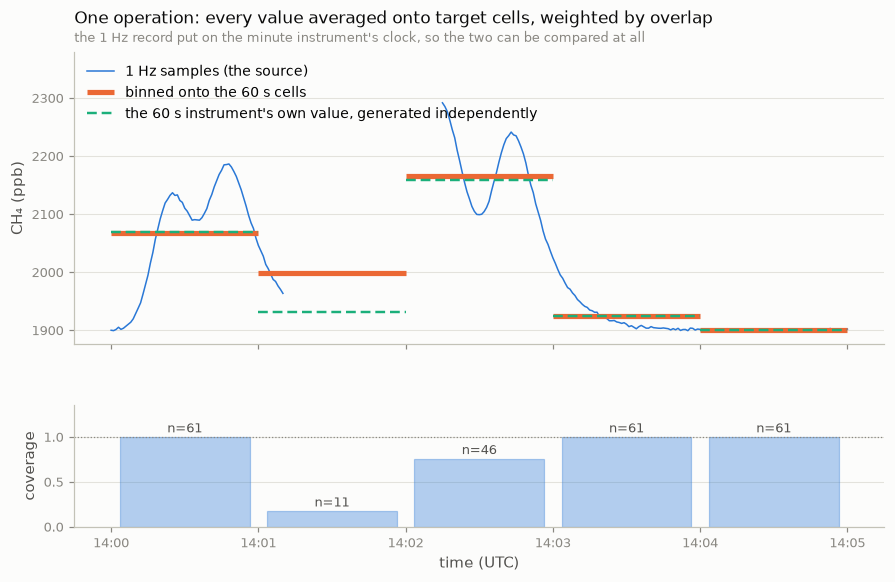

all 60 cells           : median |diff|  0.456 ppb, max  66.669 ppb
the 56 fully covered   : median |diff|  0.431 ppb, max   1.900 ppb

the worst cell has coverage 0.175 and 11 contributing samples


In [4]:
# Pick the window from the data, not by guessing: centre it on the cell with
# the least coverage, which is where the dropout is.
cov = joined["coverage_ch4"].values
centre = pd.Timestamp(joined["time"].values[int(np.argmin(cov))])
w0 = max(centre - pd.Timedelta("2min"), pd.Timestamp(fast["time"].values[0]).floor("min"))
WINDOW = (w0, w0 + pd.Timedelta("5min"))

win = joined.sel(time=slice(*WINDOW))
cell_start, cell_stop = bounds_of(win)
fast_win = fast.sel(time=slice(*WINDOW))
t_fast, v_fast = break_gaps(fast_win["time"].values, fast_win["ch4"].values)

fig, (ax, axc) = plt.subplots(
    2, 1, figsize=(9.5, 5.6), sharex=True, gridspec_kw={"height_ratios": [2.4, 1.0], "hspace": 0.3}
)
ax.plot(t_fast, v_fast, color=C1, lw=1.0, label="1 Hz samples (the source)")
ax.hlines(
    win["ch4"].values, cell_start, cell_stop, color=C2, lw=3.4, label="binned onto the 60 s cells"
)
ax.hlines(
    win["minute_ch4"].values,
    cell_start,
    cell_stop,
    color=C3,
    lw=1.6,
    ls=(0, (4, 2)),
    label="the 60 s instrument's own value, generated independently",
)
low, high = np.nanmin(v_fast), np.nanmax(v_fast)
ax.set_ylim(low - 0.05 * (high - low), high + 0.22 * (high - low))
finish(
    ax,
    "One operation: every value averaged onto target cells, weighted by overlap",
    "the 1 Hz record put on the minute instrument's clock, so the two can be compared at all",
    "CH₄ (ppb)",
    legend=True,
    loc="upper left",
)
mid = cell_start + (cell_stop - cell_start) / 2
axc.bar(
    mid,
    win["coverage_ch4"].values,
    width=(cell_stop - cell_start) * 0.88,
    color=C1,
    alpha=0.35,
    edgecolor=C1,
    lw=0.8,
)
for x, c, n in zip(mid, win["coverage_ch4"].values, win["n_source_ch4"].values):
    axc.text(x, c + 0.05, f"n={n}", ha="center", fontsize=8.2, color=INK2)
axc.axhline(1.0, color=MUTED, lw=0.8, ls=":")
axc.set_ylim(0, 1.35)
finish(axc, None, None, "coverage", "time (UTC)")
hhmm(axc)
plt.show()

diff = np.abs(joined["ch4"].values - joined["minute_ch4"].values)
full = joined["coverage_ch4"].values > 0.99
worst = int(np.argmax(diff))
print(
    f"all {diff.size} cells           : median |diff| {np.median(diff):6.3f} ppb, "
    f"max {diff.max():7.3f} ppb"
)
print(
    f"the {int(full.sum())} fully covered   : median |diff| {np.median(diff[full]):6.3f} ppb, "
    f"max {diff[full].max():7.3f} ppb"
)
print(
    f"\nthe worst cell has coverage {cov[worst]:.3f} and {joined['n_source_ch4'].values[worst]} "
    f"contributing samples"
)

The bars span the minute they are the mean of, rather than sitting as markers
at an instant, for the same reason as in notebook 03: there is no curve to read
through them.

Two things in that figure are the whole argument for carrying `coverage`.

**The orange and the green agree almost everywhere.** They were built by
completely different routes — the green by the generator integrating truth
inside each cell, the orange by TSARA averaging 1 Hz samples over the same
bounds — and across the fully covered cells they differ by less than 2 ppb on
values near 2000. That is an independent construction, not a self-consistency
check.

**Where they disagree badly, coverage says so first.** One cell is out by tens
of ppb, and it is exactly the cell the dropout hit: a fifth of its minute was
measured, and the surviving samples happened to catch a plume's rising edge.
Nothing in the *value* reveals that. `coverage` and `n_source` do, which is why
they travel automatically rather than on request.

Note also that a fully covered 60 s cell has **61** contributing samples, not
60. The 1 s cells are centred on their timestamps, so a minute contains 59
whole ones and two halves. The weighting handles it; a count would not.

---
## 3. How close is "almost everywhere"?

The number above mixes three things: the binner's arithmetic, the noise
deliberately injected into both instruments, and a deliberate 1 % spread
between the two species' plume amplitudes. Only the first is TSARA's.

So take them away one at a time. If the binner is exact, the disagreement
should fall to the injected noise and then to nothing.

In [5]:
import copy

MOVING_BACKGROUND = {
    "kind": "parametric",
    "offset": 1900.0,
    "diurnal_amplitude": 40.0,
    "drift_per_day": 60.0,
}


def gaps(seed, *, plumes, noise, spread=0.0):
    """Rebuild the campaign with one thing changed, and return the per-cell gap."""
    spec = copy.deepcopy(SPEC)
    spec["seed"] = seed
    # Push the generator's own quadrature well below anything measured here: it
    # renders a `mean` cell by averaging truth at `subsamples` points inside it,
    # and the first row of the table below is a claim at 1e-4 ppb.
    spec["instruments"]["minute"]["support"]["subsamples"] = 256
    # The dropouts belong to the figure above, not to this table: a row here
    # is meant to isolate one term, and a partly covered cell is a third one.
    spec["instruments"]["fast"].pop("dropouts", None)
    for instrument in spec["instruments"].values():
        for species in instrument["species"].values():
            # A flat background would make the no-plume rows vacuous: a constant
            # averages to itself however wrong the weights are.
            species["background"] = dict(MOVING_BACKGROUND)
            if not noise:
                species.pop("uncertainty", None)
    if plumes:
        spec["sources"]["well_pad"]["ratios"]["minute_ch4"]["relative_spread"] = spread
    else:
        spec["sources"] = {}
    built = generate(SyntheticConfig.model_validate(spec))
    got = bin_streams_onto_cells(
        dict(built.streams), cells_of(built.streams["minute"]), ["ch4", "minute_ch4"]
    )
    gap = got["ch4"].values - got["minute_ch4"].values
    return gap[got["coverage_ch4"].values > 0.99]


# One hour is 60 cells, and the spread of a statistic over 60 values is wide
# enough to argue with. Twelve seeds is 720, where the rms is good to a few
# percent -- small enough that the comparison below means something.
SEEDS = range(1, 13)

# If the binner is exact, the only thing left between the two instruments is
# the noise each had injected: 1.5 ppb averaged over 61 samples, against 0.4.
predicted = float(np.hypot(1.5 / np.sqrt(61), 0.4))
print(f"predicted sigma of the difference, declared noise only: {predicted:.4f} ppb\n")

print(f"{'campaign':46} {'cells':>6} {'rms gap':>10}  {'vs predicted':>12}")
for label, kwargs in [
    ("a moving background, no plumes, no noise", {"plumes": False, "noise": False}),
    ("plumes too, still no noise", {"plumes": True, "noise": False}),
    ("the declared noise, no plumes", {"plumes": False, "noise": True}),
    ("plumes and noise, identical amplitudes", {"plumes": True, "noise": True}),
    ("as configured: a 1% spread between them", {"plumes": True, "noise": True, "spread": 0.01}),
]:
    pooled = np.concatenate([gaps(seed, **kwargs) for seed in SEEDS])
    rms = float(np.sqrt((pooled**2).mean()))
    print(f"{label:46} {pooled.size:>6} {rms:>10.2e}  {rms / predicted:>11.3f}x")

predicted sigma of the difference, declared noise only: 0.4437 ppb

campaign                                        cells    rms gap  vs predicted
a moving background, no plumes, no noise          720   9.75e-05        0.000x


plumes too, still no noise                        720   1.29e-01        0.291x
the declared noise, no plumes                     720   4.41e-01        0.994x


plumes and noise, identical amplitudes            720   4.58e-01        1.033x


as configured: a 1% spread between them           720   8.80e-01        1.983x


Read that ladder from the top.

**The weighting is right.** With a background that moves but no plumes and no
noise, TSARA's overlap-weighted average of the 1 Hz record and the generator's
own integral of the same truth agree to an rms of about **1 × 10⁻⁴ ppb**, on a
background sweeping several ppb. Two independent constructions, five decimal
places.

**Sharp structure costs about 0.13 ppb, and it is not the binner's.** The fast
instrument takes *point samples* of a plume some 20 s wide; the minute
instrument *integrates* the same plume. One second of sampling grid is the
whole difference between them, and no weighting scheme can close it. It is a
property of the data.

**The binner is transparent to noise, to 0.6 %.** With the declared noise and
nothing else, the measured rms gap over 720 cells is **0.994×** what the two
declared sigmas predict. This is the row that matters: the whole uncertainty
model assumes that averaging does to the error exactly what the algebra says,
and here that assumption is tested against draws rather than against more
algebra.

**And the rows add in quadrature, as they must.** Plumes and noise together
give 1.033×, against √(0.994² + 0.291²) = 1.036 predicted from the two rows
above. Nothing is double-counted and nothing is missing.

The last row is the deliberate 1 % amplitude spread between the two species —
the largest term in the figure further up, and the one piece of that
disagreement that is neither the support nor the noise nor TSARA.

---
## 4. The direction that is refused

The operation is symmetric in the code and **must not be** in use. Averaging a
fast stream onto slow cells discards resolution the slow instrument never had,
which is honest. Doing it the other way round — evaluating a 60 s mean on 1 s
cells — invents no *value*, since every row holds a number the instrument
really reported, but it invents **rows**.

Nothing in the output would give it away. A replicated row reports
`coverage = 1.00`, because the target cell really is fully covered by source
data, and `n_source = 1`, which is also what a legitimately sparse canister
measurement reports. The two numbers that exist to flag a badly determined
value both say the value is perfect.

Here is what a naive upsample of the minute instrument would look like, built
by hand, beside what the instrument actually measured.

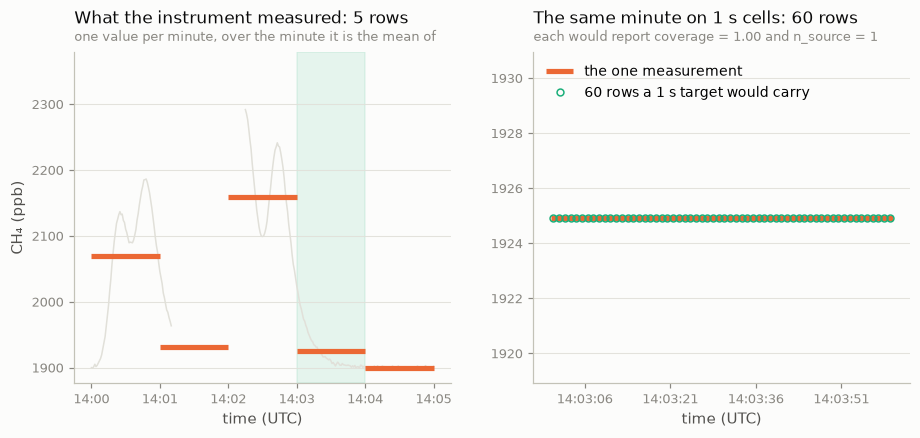

In [6]:
# Built with np.repeat, NOT by TSARA -- the next cell is what TSARA does when
# asked for this. Sixty copies of each minute, one per second.
naive_rows = np.repeat(win["minute_ch4"].values, 60)
naive_clock = pd.date_range(WINDOW[0] + pd.Timedelta("0.5s"), periods=naive_rows.size, freq="1s")

zoom = (WINDOW[0] + pd.Timedelta("3min"), WINDOW[0] + pd.Timedelta("4min"))
in_zoom = (naive_clock >= zoom[0]) & (naive_clock < zoom[1])
zoom_win = win.sel(time=slice(*zoom))
zoom_start, zoom_stop = bounds_of(zoom_win)

fig, (axl, axr) = plt.subplots(1, 2, figsize=(9.8, 3.9), gridspec_kw={"wspace": 0.22})
axl.plot(t_fast, v_fast, color=GRID, lw=1.0, zorder=1)
axl.hlines(win["minute_ch4"].values, cell_start, cell_stop, color=C2, lw=3.4, zorder=3)
axl.set_ylim(low - 0.05 * (high - low), high + 0.22 * (high - low))
axl.axvspan(zoom[0], zoom[1], color=C3, alpha=0.10, zorder=0)
finish(
    axl,
    f"What the instrument measured: {win.sizes['time']} rows",
    "one value per minute, over the minute it is the mean of",
    "CH₄ (ppb)",
    "time (UTC)",
)
hhmm(axl)
axr.hlines(
    zoom_win["minute_ch4"].values,
    zoom_start,
    zoom_stop,
    color=C2,
    lw=3.4,
    zorder=2,
    label="the one measurement",
)
axr.plot(
    naive_clock[in_zoom],
    naive_rows[in_zoom],
    "o",
    color=C3,
    ms=4.5,
    mfc="none",
    mew=1.0,
    zorder=3,
    label=f"{int(in_zoom.sum())} rows a 1 s target would carry",
)
axr.set_ylim(zoom_win["minute_ch4"].values[0] - 6, zoom_win["minute_ch4"].values[0] + 6)
finish(
    axr,
    f"The same minute on 1 s cells: {int(in_zoom.sum())} rows",
    "each would report coverage = 1.00 and n_source = 1",
    None,
    "time (UTC)",
    legend=True,
    loc="upper left",
)
hhmm(axr, "%H:%M:%S")
axr.xaxis.set_major_locator(mdates.SecondLocator(interval=15))
plt.show()

In [7]:
from tsara.align import TsaraAlignError

edges = np.arange(int(pd.Timestamp(WINDOW[0]).value), int(pd.Timestamp(WINDOW[1]).value), SECOND)
one_second = CellBounds(start_ns=edges, stop_ns=edges + SECOND)

try:
    bin_streams_onto_cells({"minute": minute}, one_second)
except TsaraAlignError as refused:
    print(refused)

Stream 'minute' has 60 s cells and the target cells are 1 s, so one of its measurements would fill 60 target cells on its own. Evaluating it on a shorter support is resolution the instrument never had (METHODS §11.2), and the replicated rows would enter a fit as independent measurements. Bin onto cells at least as wide, pair on the wider-supported stream, or — for a smooth non-gas field — interpolate it with tsara.align.auxiliary (§11.6).


The refusal counts, on the actual overlaps, how many target cells fall
*entirely* inside one source cell. That is a deliberate choice over comparing
the two median widths, which would need a tolerance: real analyzers disagree
about their own nominal rate, and two in the 2026 archive measure 0.993 s and
1.024 s against a nominal 1 s. Binning one onto the other replicates nothing,
and a strict width rule would refuse it over a 3 % difference. Counting whole
contained cells never reaches two on jitter, however the medians compare.

A grid half a period out of phase with an equal-width source is not refused
either: every source cell then straddles two targets and wholly contains
neither. That case is lossy for a different reason and is warned about
separately.

The escape route for the case that is genuinely wanted — a smooth field on a
finer clock, a wind direction against 1 Hz methane — is the one that already
exists. `tsara.align.auxiliary` interpolates it under a gap guard, and refuses
any variable declaring `role: gas`. That is stage 5 of this walkthrough.